#Bibliotecas

In [21]:
import os
import copy
import warnings
import itertools
import datetime as dt
import pandas as pd
import numpy as np
import random # Usado para random.sample e random.shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf
from dataclasses import dataclass, field
from typing import List, Dict, Optional
from scipy.stats import norm, skew, kurtosis, truncnorm, jarque_bera, shapiro # Importar diretamente as funções
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from scipy.optimize import curve_fit
from statsmodels.graphics.gofplots import qqplot
from multiprocessing import Pool
import random
import traceback # Importar para printar o traceback em caso de erro

# Importar nas classes quando usar função standalone

warnings.filterwarnings("ignore")

In [2]:
!git clone https://github.com/gilbertogilfgp/Mercado-Artificial-Fiis.git
%cd /content/Mercado-Artificial-Fiis

import sys
sys.path.append('/content/Mercado-Artificial-Fiis')

!pip install numpy pandas matplotlib scipy statsmodels yfinance seaborn



Cloning into 'Mercado-Artificial-Fiis'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (150/150), done.
remote: Total 162 (delta 82), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 458.13 KiB | 2.21 MiB/s, done.
Resolving deltas: 100% (82/82), done.
/content/Mercado-Artificial-Fiis


In [3]:
from src.simulacao import simular_mercado_e_plotar, plotar_resultado, SIM_PARAMS

# IFIX

In [4]:
url = "https://docs.google.com/spreadsheets/d/1bBVbP7GH3JPcRPPn0qydQJ6H16I3yDbz/export?format=csv"

df = pd.read_csv(url, index_col="Date", parse_dates=True, dayfirst=True)
df.index = pd.to_datetime(df.index, format='%Y-%m-%d')
df["Close"] = df["Close"].astype(str).str.replace(".", "")
df["Close"] = df["Close"].astype(str).str.replace(",", ".").astype(float)
df = df.sort_index(ascending=True)
df_ifix = df.rename(columns={'Close': 'IFIX'})
#df_ifix = df_ifix[:-3]
df_ifix=df_ifix[-1008:]

retorno_diario_bench = np.log(df_ifix).diff().dropna()
serie_empirica = retorno_diario_bench.dropna()

# Rodar o Mercado

In [5]:
parametros_sistema = pd.read_csv('/content/Mercado-Artificial-Fiis/notebooks/dados/parametros_sistema_calibrados.csv').to_numpy()[0]

parametros_sistema

array([0.84822756, 0.69540723, 0.87855894, 0.15595803, 0.07548527])

In [6]:
params = copy.deepcopy(SIM_PARAMS)
NUM_DIAS    = 60

# Rodar sem plotar
resultado = simular_mercado_e_plotar(
    parametros_sistema=parametros_sistema,
    num_dias=NUM_DIAS,
    sim_params=params,
    imprimir=False,
)

Total de Agentes: 800
⚡ Choque aleatório positivo no dia 29 (intensidade 0.31)
⚡ Choque aleatório negativo no dia 42 (intensidade 0.35)


In [7]:
precos    = resultado[0]
log_return  = resultado[1]
volatilidade = resultado[2]
sentimento = resultado[4]

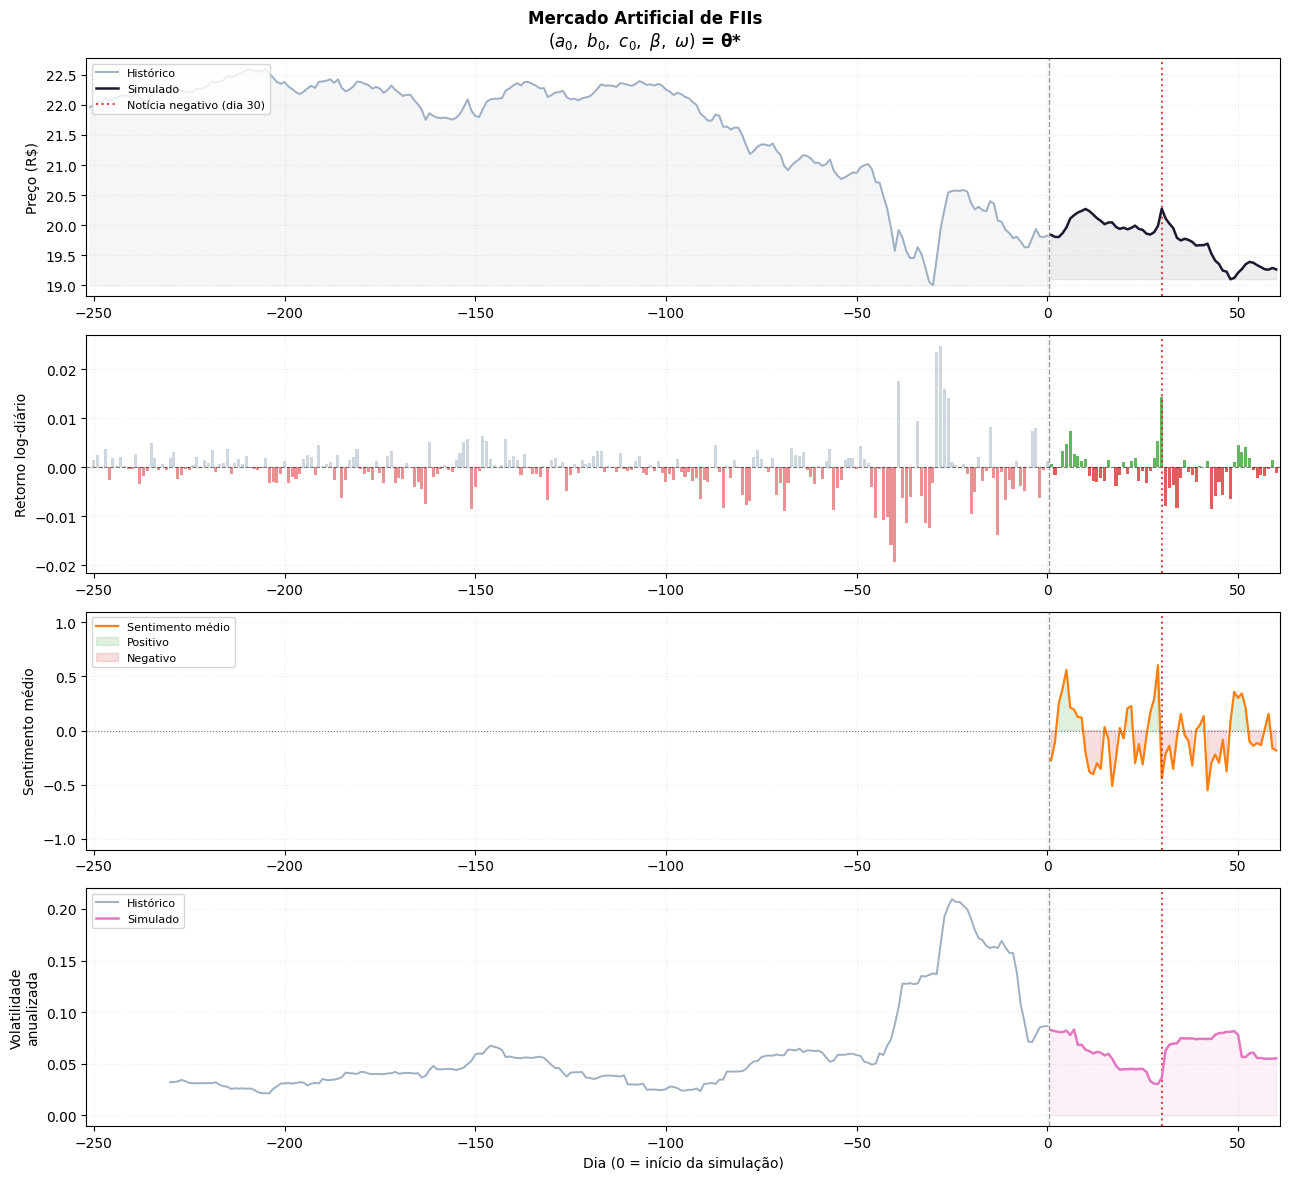

In [8]:
plotar_resultado(resultado, params=params, num_dias=NUM_DIAS)

# Fatos Estilizados

In [9]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 17.7 MB/s eta 0:00:00


In [10]:
sys.path.insert(0, '/content/Mercado-Artificial-Fiis/notebooks/funcoes')
from fatos_estilizados import (
    plot_intermitencia,
    plot_acf_retornos,
    plot_power_law,
    plot_gaussianidade_agregacional,
    calcular_residuos_garch,
)

## Janela de 60 dias

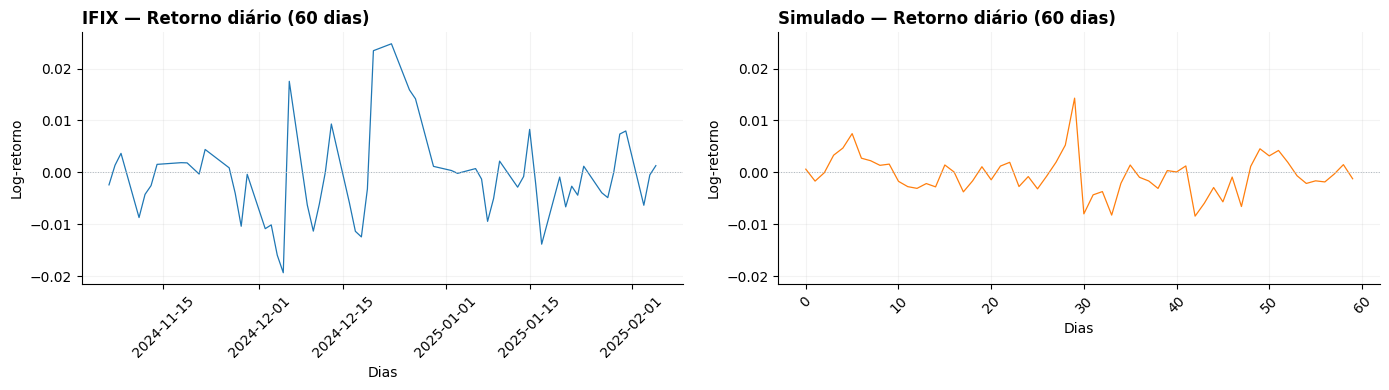

In [11]:
# Fato 01 — Intermitência
from IPython.display import display

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plt.close(fig)

plot_intermitencia(retorno_diario_bench[-NUM_DIAS:],  titulo="IFIX — Retorno diário (60 dias)",    cor="tab:blue",   ax=ax1)
plot_intermitencia(log_return[-NUM_DIAS:],      titulo="Simulado — Retorno diário (60 dias)", cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

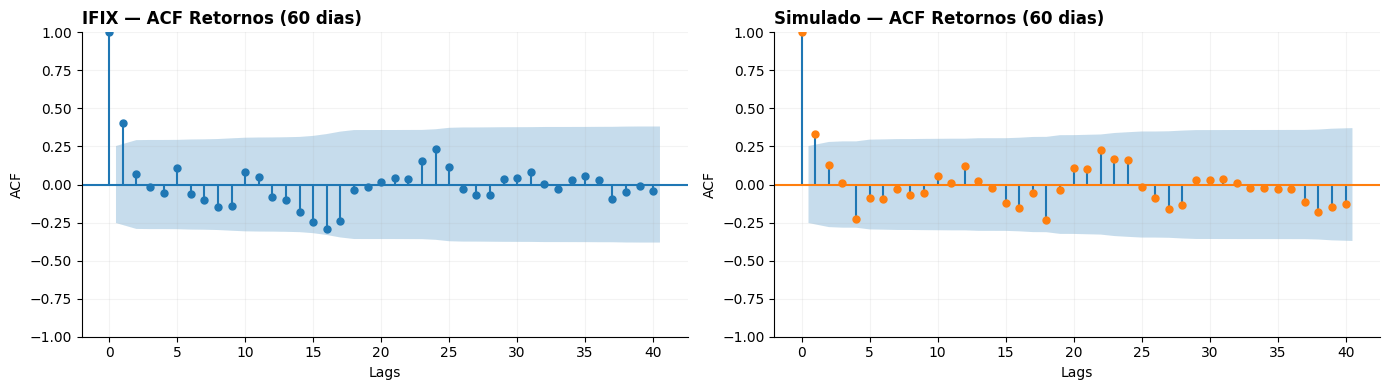

In [12]:
# Fato 02 — Autocorrelação dos retornos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plt.close(fig)

plot_acf_retornos(retorno_diario_bench[-NUM_DIAS:], lags= 40, titulo="IFIX — ACF Retornos (60 dias)",    cor="tab:blue",   ax=ax1)
plot_acf_retornos(log_return[-NUM_DIAS:],     lags= 40,      titulo="Simulado — ACF Retornos (60 dias)", cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

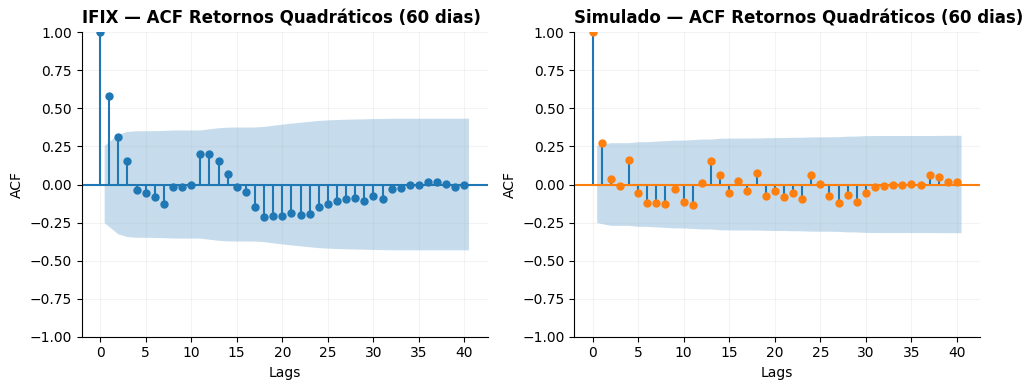

In [13]:
# Fato 03 — Autocorrelação dos retornos quadráticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plt.close(fig)

plot_acf_retornos(retorno_diario_bench[-NUM_DIAS:]**2, lags=40, titulo="IFIX — ACF Retornos Quadráticos (60 dias)",    cor="tab:blue",   ax=ax1)
plot_acf_retornos(log_return[-NUM_DIAS:]**2, lags=40,           titulo="Simulado — ACF Retornos Quadráticos (60 dias)", cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

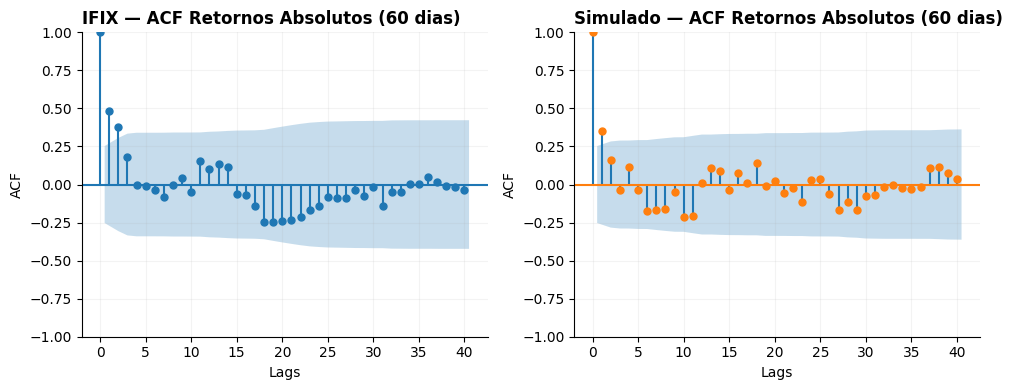

In [14]:
# Fato 04 — Autocorrelação dos retornos absolutos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plt.close(fig)

plot_acf_retornos(abs(retorno_diario_bench[-NUM_DIAS:]), lags=40, titulo="IFIX — ACF Retornos Absolutos (60 dias)",    cor="tab:blue",   ax=ax1)
plot_acf_retornos(abs(log_return[-NUM_DIAS:]), lags=40,           titulo="Simulado — ACF Retornos Absolutos (60 dias)", cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

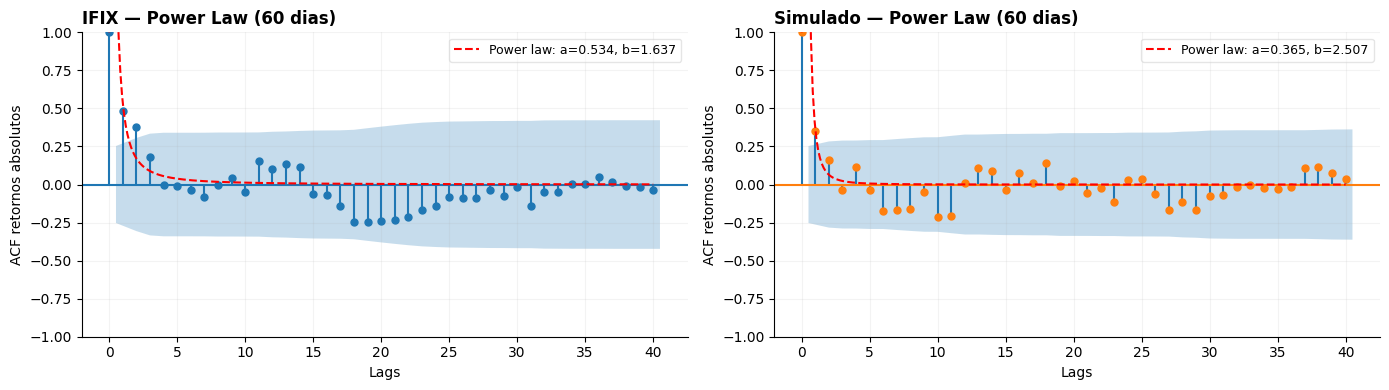

IFIX    — a=0.5340, b=1.6374
Simulado — a=0.3648,  b=2.5065


In [15]:
# Fato 05 — Decaimento em lei de potência (ACF retornos absolutos)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plt.close(fig)

_, popt_ifix = plot_power_law(retorno_diario_bench[-NUM_DIAS:], titulo="IFIX — Power Law (60 dias)",    lags=40, cor="tab:blue",   ax=ax1)
_, popt_sim  = plot_power_law(log_return[-NUM_DIAS:],           titulo="Simulado — Power Law (60 dias)", lags=40, cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

print(f"IFIX    — a={popt_ifix[0]:.4f}, b={popt_ifix[1]:.4f}")
print(f"Simulado — a={popt_sim[0]:.4f},  b={popt_sim[1]:.4f}")

In [25]:
from scipy.stats import kurtosis as kurt

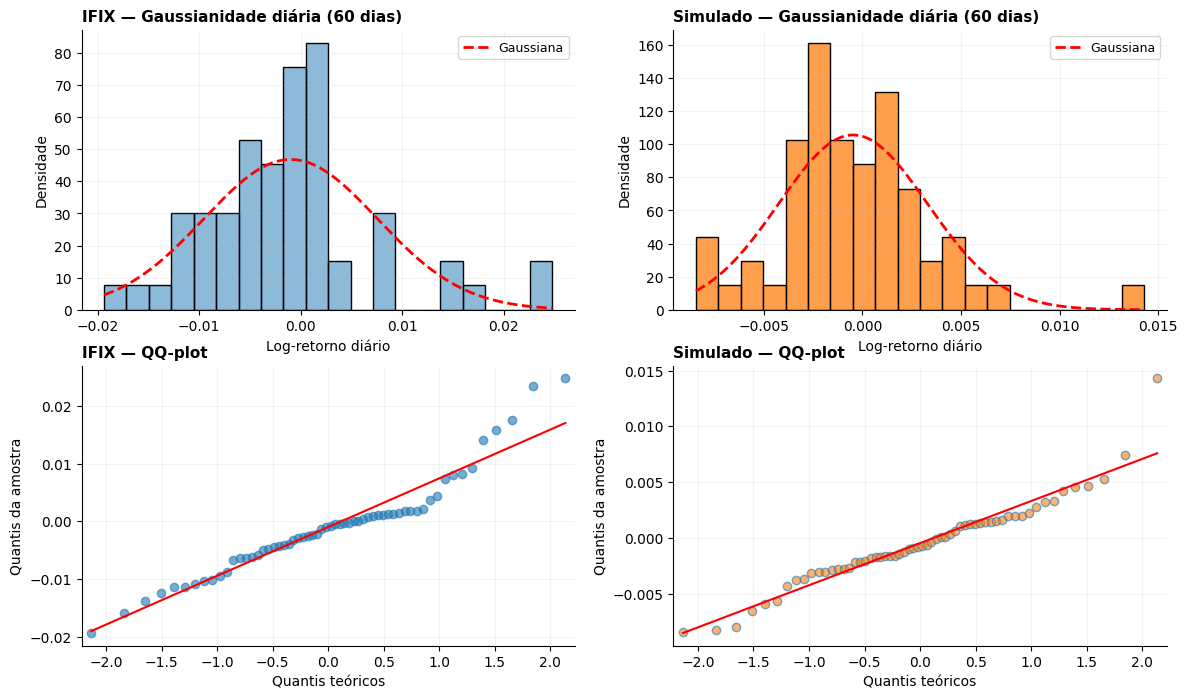

Curtose IFIX:     4.4099
Curtose Simulado: 5.7268


In [26]:
# Fato 06 — Gaussianidade agregacional + QQ-plot (somente diário — janela 60 dias)
from statsmodels.graphics.gofplots import qqplot

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plt.close(fig)

for col, (retornos, titulo, cor) in enumerate([
    (retorno_diario_bench[-NUM_DIAS:], "IFIX",     "tab:blue"),
    (log_return[-NUM_DIAS:],           "Simulado", "tab:orange"),
]):
    # Histograma + gaussiana
    ax_hist = axes[0, col]
    sns.histplot(retornos, bins=20, stat="density", color=cor, ax=ax_hist)
    x = np.linspace(retornos.min(), retornos.max(), 200)
    ax_hist.plot(x, norm.pdf(x, retornos.mean(), retornos.std()),
                 color="red", lw=2, ls="--", label="Gaussiana")
    ax_hist.set_title(f"{titulo} — Gaussianidade diária (60 dias)",
                      fontsize=11, fontweight="bold", loc="left")
    ax_hist.set_xlabel("Log-retorno diário")
    ax_hist.set_ylabel("Densidade")
    ax_hist.legend(fontsize=9)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)
    ax_hist.grid(True, alpha=0.15)

    # QQ-plot
    ax_qq = axes[1, col]

    qqplot(np.sort(retornos, axis = 0), line="s", ax=ax_qq, markerfacecolor=cor, alpha=0.6)
    plt.close()
    ax_qq.set_title(f"{titulo} — QQ-plot", fontsize=11, fontweight="bold", loc="left")
    ax_qq.set_xlabel("Quantis teóricos")
    ax_qq.set_ylabel("Quantis da amostra")
    ax_qq.spines["top"].set_visible(False)
    ax_qq.spines["right"].set_visible(False)
    ax_qq.grid(True, alpha=0.15)



display(fig)

print(f"Curtose IFIX:     {float(kurt(retorno_diario_bench[-NUM_DIAS:], fisher=False, bias=True)):.4f}")
print(f"Curtose Simulado: {float(kurt(log_return[-NUM_DIAS:],           fisher=False, bias=True)):.4f}")

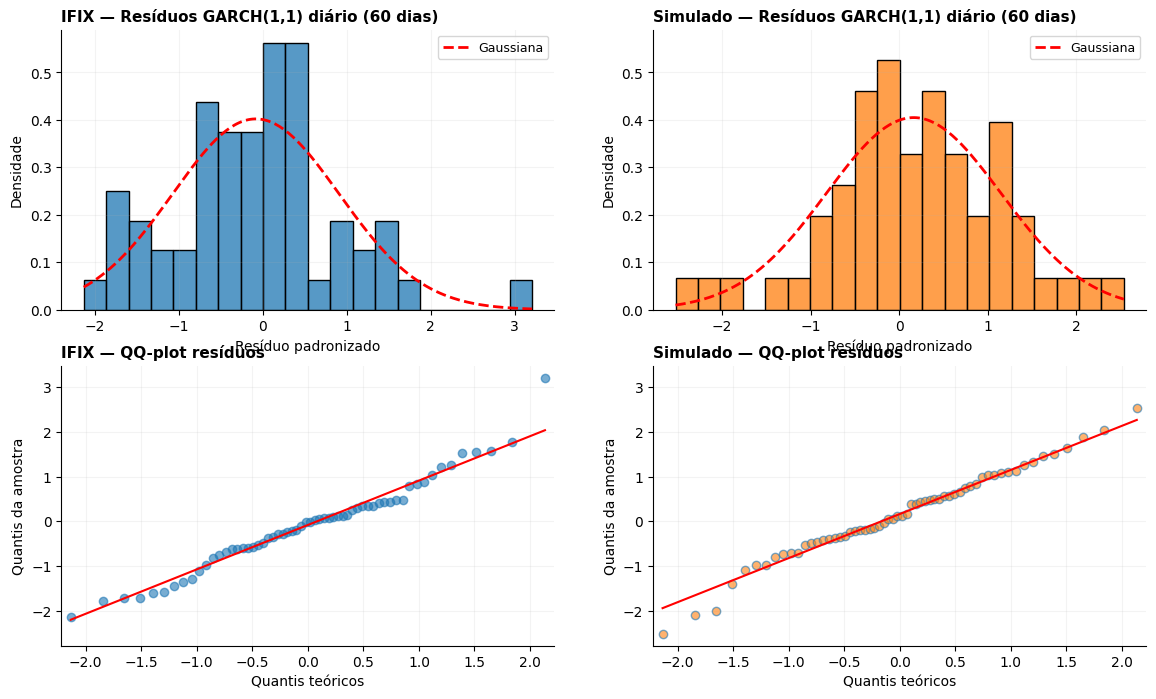

Curtose resíduos IFIX:     3.8211
Curtose resíduos Simulado: 3.3214


In [27]:
# Fato 07 — Caudas pesadas condicionais (resíduos GARCH — escala diária)
residuos_ifix = calcular_residuos_garch(retorno_diario_bench[-NUM_DIAS:], escalas=[1])[0]
residuos_sim  = calcular_residuos_garch(log_return[-NUM_DIAS:],           escalas=[1])[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plt.close(fig)

for col, (residuos, titulo, cor) in enumerate([
    (residuos_ifix, "IFIX",     "tab:blue"),
    (residuos_sim,  "Simulado", "tab:orange"),
]):
    # Histograma + gaussiana
    ax_hist = axes[0, col]
    sns.histplot(residuos, bins=20, stat="density", color=cor, ax=ax_hist)
    x = np.linspace(residuos.min(), residuos.max(), 200)
    ax_hist.plot(x, norm.pdf(x, residuos.mean(), residuos.std()),
                 color="red", lw=2, ls="--", label="Gaussiana")
    ax_hist.set_title(f"{titulo} — Resíduos GARCH(1,1) diário (60 dias)",
                      fontsize=11, fontweight="bold", loc="left")
    ax_hist.set_xlabel("Resíduo padronizado")
    ax_hist.set_ylabel("Densidade")
    ax_hist.legend(fontsize=9)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)
    ax_hist.grid(True, alpha=0.15)

    # QQ-plot
    ax_qq = axes[1, col]
    qqplot(np.sort(residuos, axis=0), line="s", ax=ax_qq, markerfacecolor=cor, alpha=0.6)
    plt.close()
    ax_qq.set_title(f"{titulo} — QQ-plot resíduos", fontsize=11, fontweight="bold", loc="left")
    ax_qq.set_xlabel("Quantis teóricos")
    ax_qq.set_ylabel("Quantis da amostra")
    ax_qq.spines["top"].set_visible(False)
    ax_qq.spines["right"].set_visible(False)
    ax_qq.grid(True, alpha=0.15)

# Igualar escalas Y
y_max_hist = max(axes[0, 0].get_ylim()[1], axes[0, 1].get_ylim()[1])
axes[0, 0].set_ylim(0, y_max_hist)
axes[0, 1].set_ylim(0, y_max_hist)

y_min_qq = min(axes[1, 0].get_ylim()[0], axes[1, 1].get_ylim()[0])
y_max_qq = max(axes[1, 0].get_ylim()[1], axes[1, 1].get_ylim()[1])
axes[1, 0].set_ylim(y_min_qq, y_max_qq)
axes[1, 1].set_ylim(y_min_qq, y_max_qq)

display(fig)

print(f"Curtose resíduos IFIX:     {float(kurt(residuos_ifix, fisher=False, bias=True)):.4f}")
print(f"Curtose resíduos Simulado: {float(kurt(residuos_sim,  fisher=False, bias=True)):.4f}")

## Janela de 500 dias

### Simulação

In [28]:
params = copy.deepcopy(SIM_PARAMS)
NUM_DIAS    = 500

# Rodar sem plotar
resultado = simular_mercado_e_plotar(
    parametros_sistema=parametros_sistema,
    num_dias=NUM_DIAS,
    sim_params=params,
    imprimir=False,
)

Total de Agentes: 800
⚡ Choque aleatório positivo no dia 28 (intensidade 0.69)
⚡ Choque aleatório negativo no dia 42 (intensidade 0.56)
⚡ Choque aleatório negativo no dia 69 (intensidade 0.64)
Imovel atualizado: Valor: R$1,083,437.03
Imovel atualizado: Valor: R$2,153,437.03
[FII] Imóveis atualizados; reinvestido: R$26,874.06
⚡ Choque aleatório negativo no dia 142 (intensidade 0.58)
⚡ Choque aleatório negativo no dia 145 (intensidade 0.63)
⚡ Choque aleatório negativo no dia 156 (intensidade 0.65)
Imovel atualizado: Valor: R$1,167,008.13
Imovel atualizado: Valor: R$2,311,908.13
[FII] Imóveis atualizados; reinvestido: R$15,461.03
⚡ Choque aleatório negativo no dia 261 (intensidade 0.49)
⚡ Choque aleatório negativo no dia 280 (intensidade 0.56)
⚡ Choque aleatório negativo no dia 288 (intensidade 0.48)
⚡ Choque aleatório negativo no dia 295 (intensidade 0.54)
⚡ Choque aleatório negativo no dia 305 (intensidade 0.56)
Imovel atualizado: Valor: R$1,253,651.30
Imovel atualizado: Valor: R$2,478,

In [29]:
precos_500    = resultado[0]
log_return_500  = resultado[1]
volatilidade_500 = resultado[2]
sentimento_500 = resultado[4]

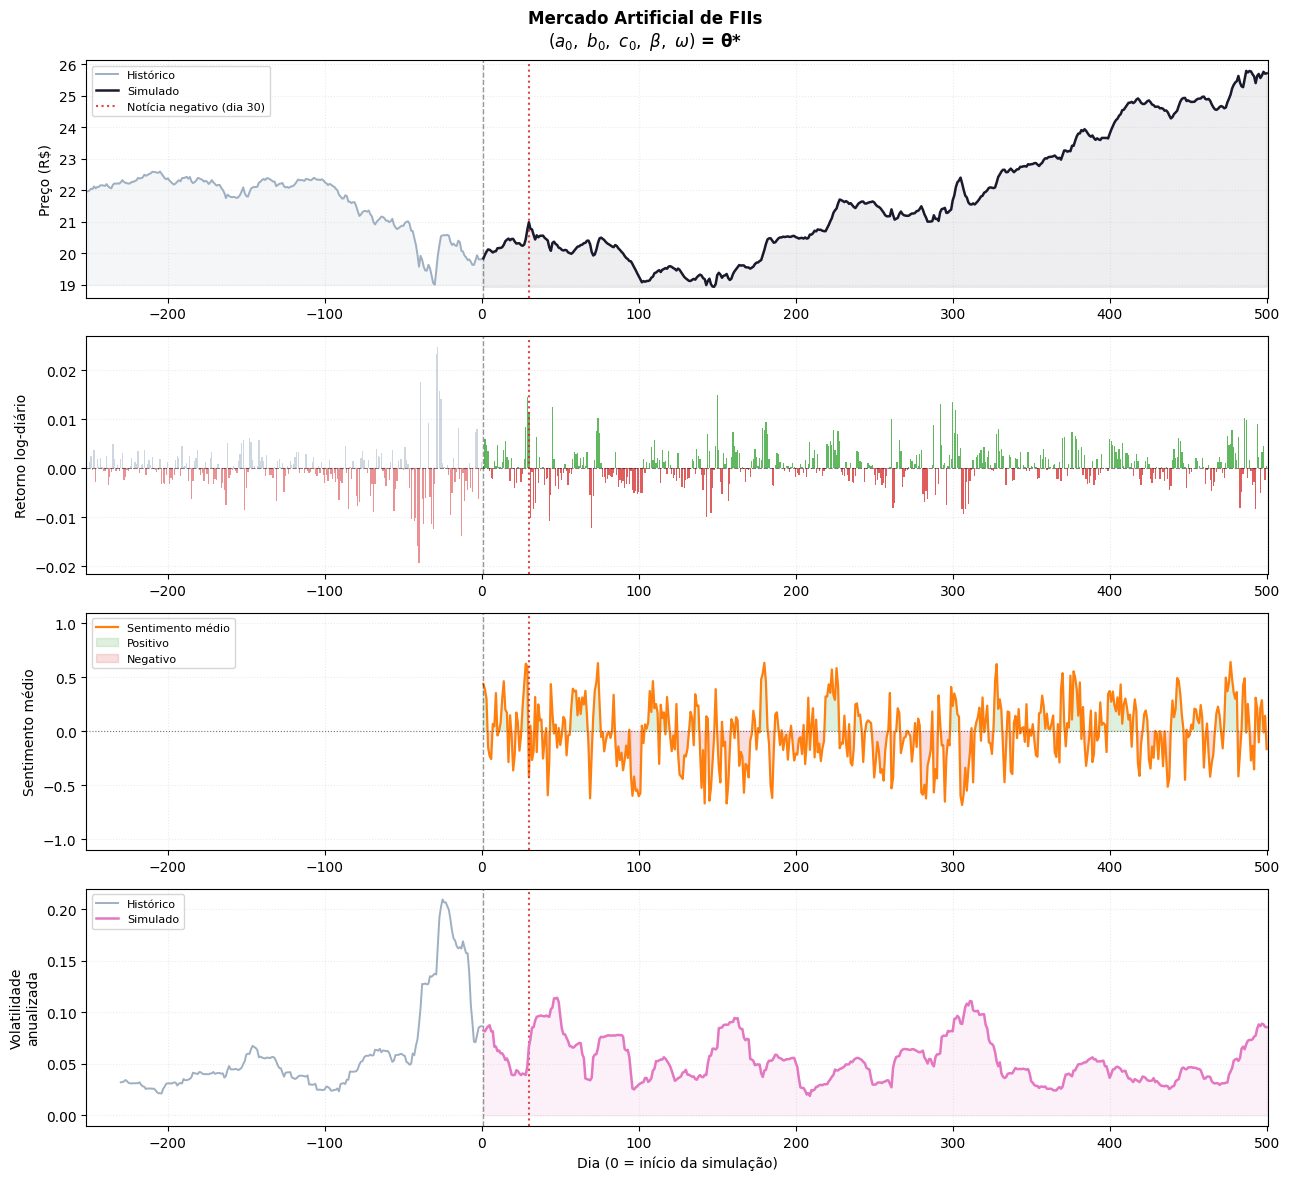

In [30]:
plotar_resultado(resultado, params=params, num_dias=NUM_DIAS)

### Fatos

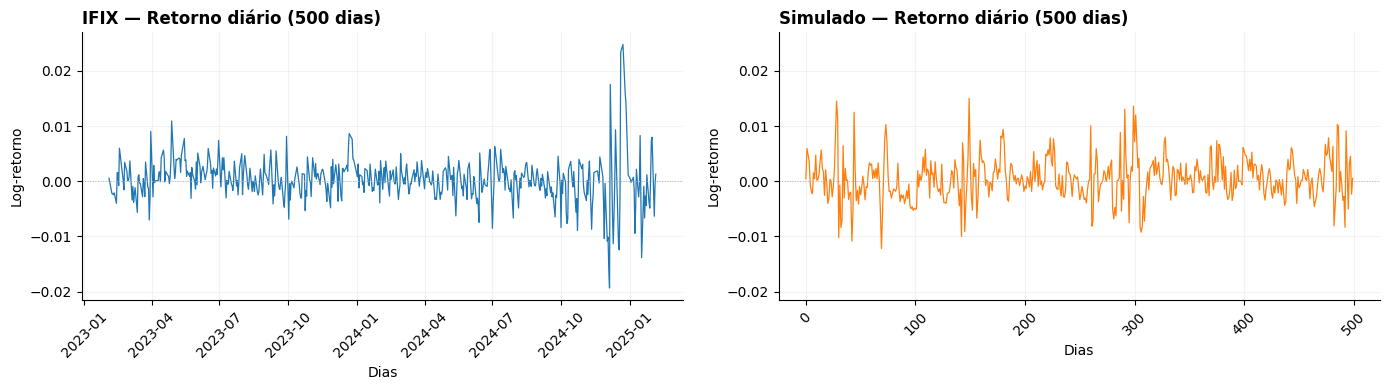

In [31]:
# Fato 01 — Intermitência
from IPython.display import display

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plt.close(fig)

plot_intermitencia(retorno_diario_bench[-NUM_DIAS:],  titulo="IFIX — Retorno diário (500 dias)",    cor="tab:blue",   ax=ax1)
plot_intermitencia(log_return_500[-NUM_DIAS:],      titulo="Simulado — Retorno diário (500 dias)", cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

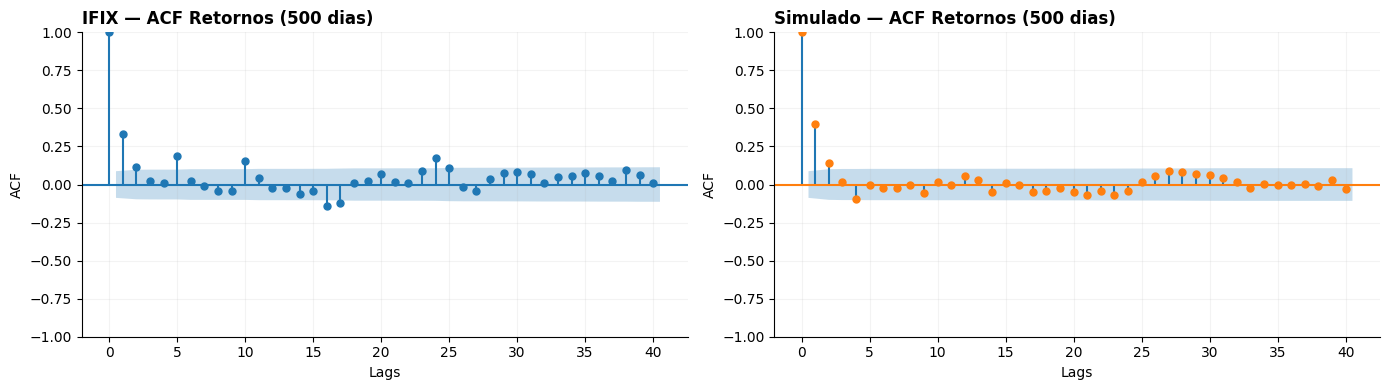

In [32]:
# Fato 02 — Autocorrelação dos retornos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plt.close(fig)

plot_acf_retornos(retorno_diario_bench[-NUM_DIAS:], lags= 40, titulo="IFIX — ACF Retornos (500 dias)",    cor="tab:blue",   ax=ax1)
plot_acf_retornos(log_return_500[-NUM_DIAS:],     lags= 40,      titulo="Simulado — ACF Retornos (500 dias)", cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

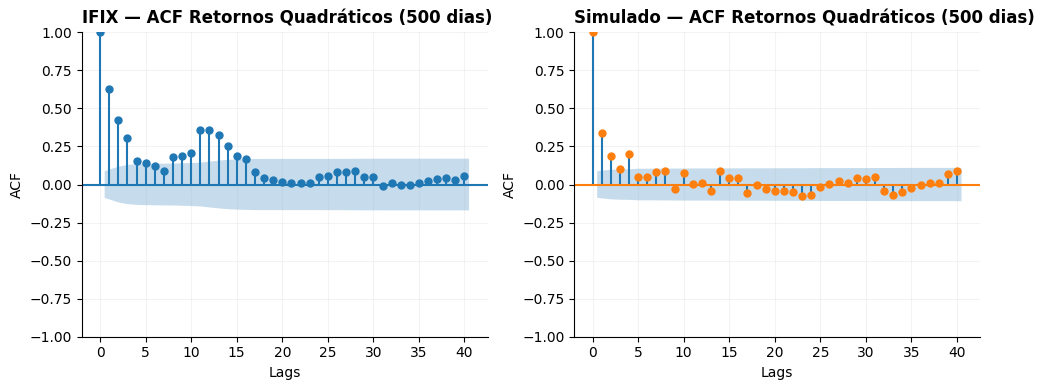

In [33]:
# Fato 03 — Autocorrelação dos retornos quadráticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plt.close(fig)

plot_acf_retornos(retorno_diario_bench[-NUM_DIAS:]**2, lags=40, titulo="IFIX — ACF Retornos Quadráticos (500 dias)",    cor="tab:blue",   ax=ax1)
plot_acf_retornos(log_return_500[-NUM_DIAS:]**2, lags=40,           titulo="Simulado — ACF Retornos Quadráticos (500 dias)", cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

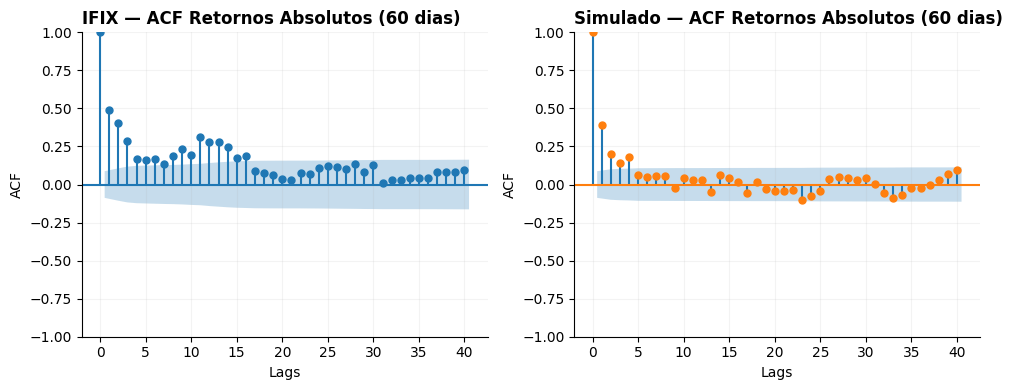

In [34]:
# Fato 04 — Autocorrelação dos retornos absolutos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plt.close(fig)

plot_acf_retornos(abs(retorno_diario_bench[-NUM_DIAS:]), lags=40, titulo="IFIX — ACF Retornos Absolutos (60 dias)",    cor="tab:blue",   ax=ax1)
plot_acf_retornos(abs(log_return_500[-NUM_DIAS:]), lags=40,           titulo="Simulado — ACF Retornos Absolutos (60 dias)", cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

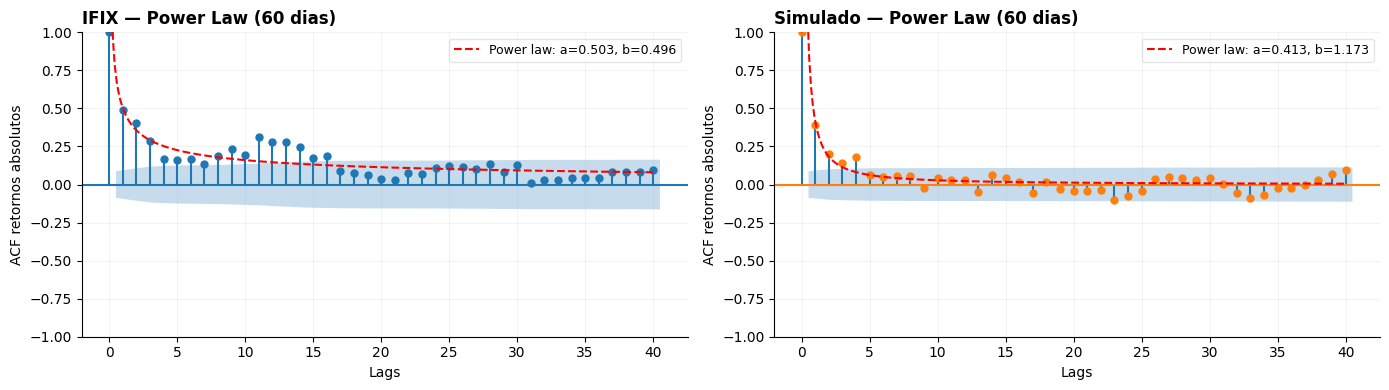

IFIX    — a=0.5026, b=0.4965
Simulado — a=0.4132,  b=1.1732


In [35]:
# Fato 05 — Decaimento em lei de potência (ACF retornos absolutos)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plt.close(fig)

_, popt_ifix = plot_power_law(retorno_diario_bench[-NUM_DIAS:], titulo="IFIX — Power Law (60 dias)",    lags=40, cor="tab:blue",   ax=ax1)
_, popt_sim  = plot_power_law(log_return_500[-NUM_DIAS:],           titulo="Simulado — Power Law (60 dias)", lags=40, cor="tab:orange", ax=ax2)

# Igualar escala Y
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

display(fig)

print(f"IFIX    — a={popt_ifix[0]:.4f}, b={popt_ifix[1]:.4f}")
print(f"Simulado — a={popt_sim[0]:.4f},  b={popt_sim[1]:.4f}")

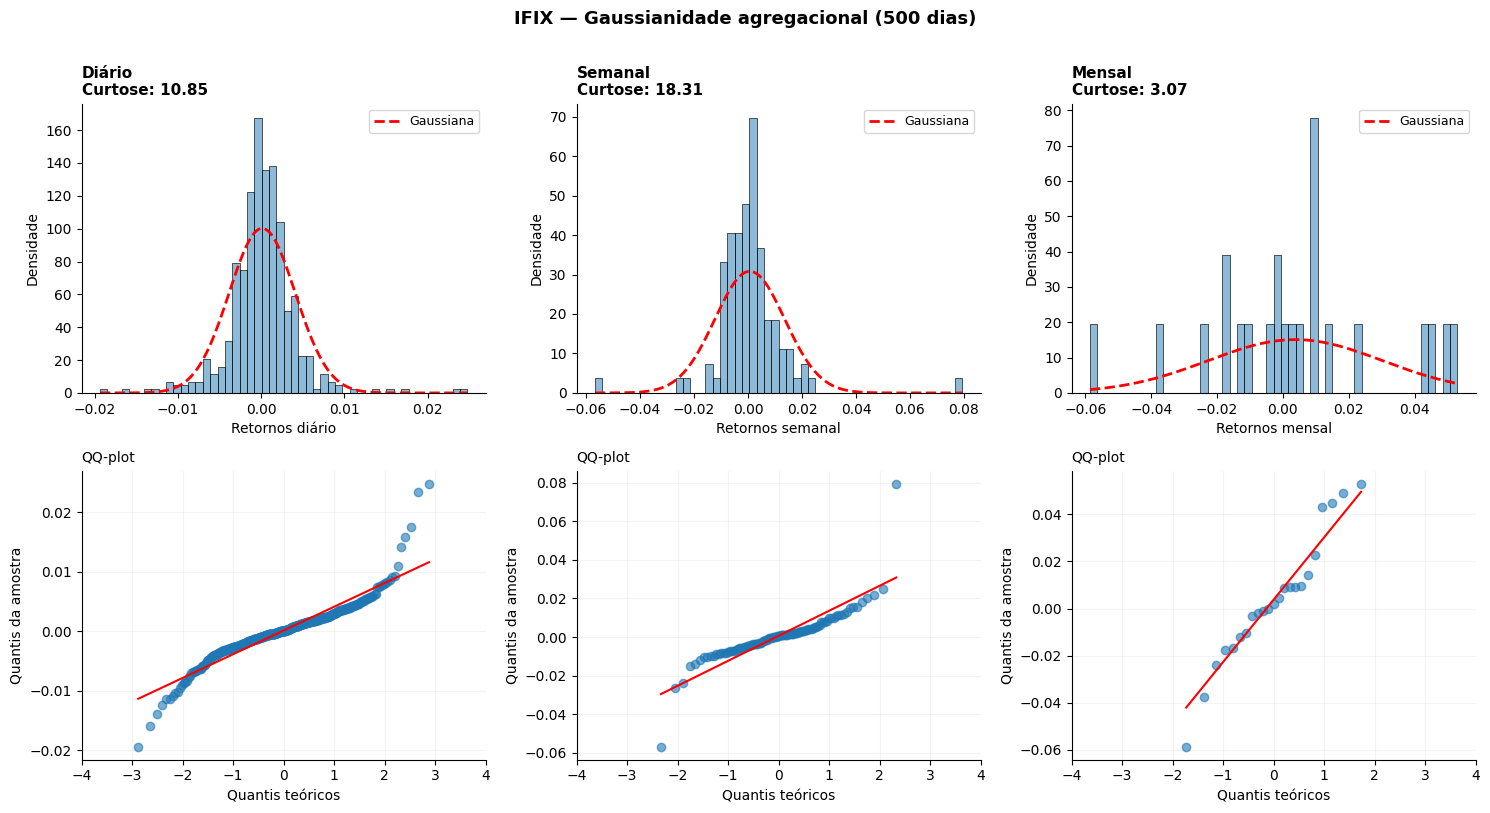

Curtose Diário: 10.8459
Curtose Semanal: 18.3111
Curtose Mensal: 3.0676


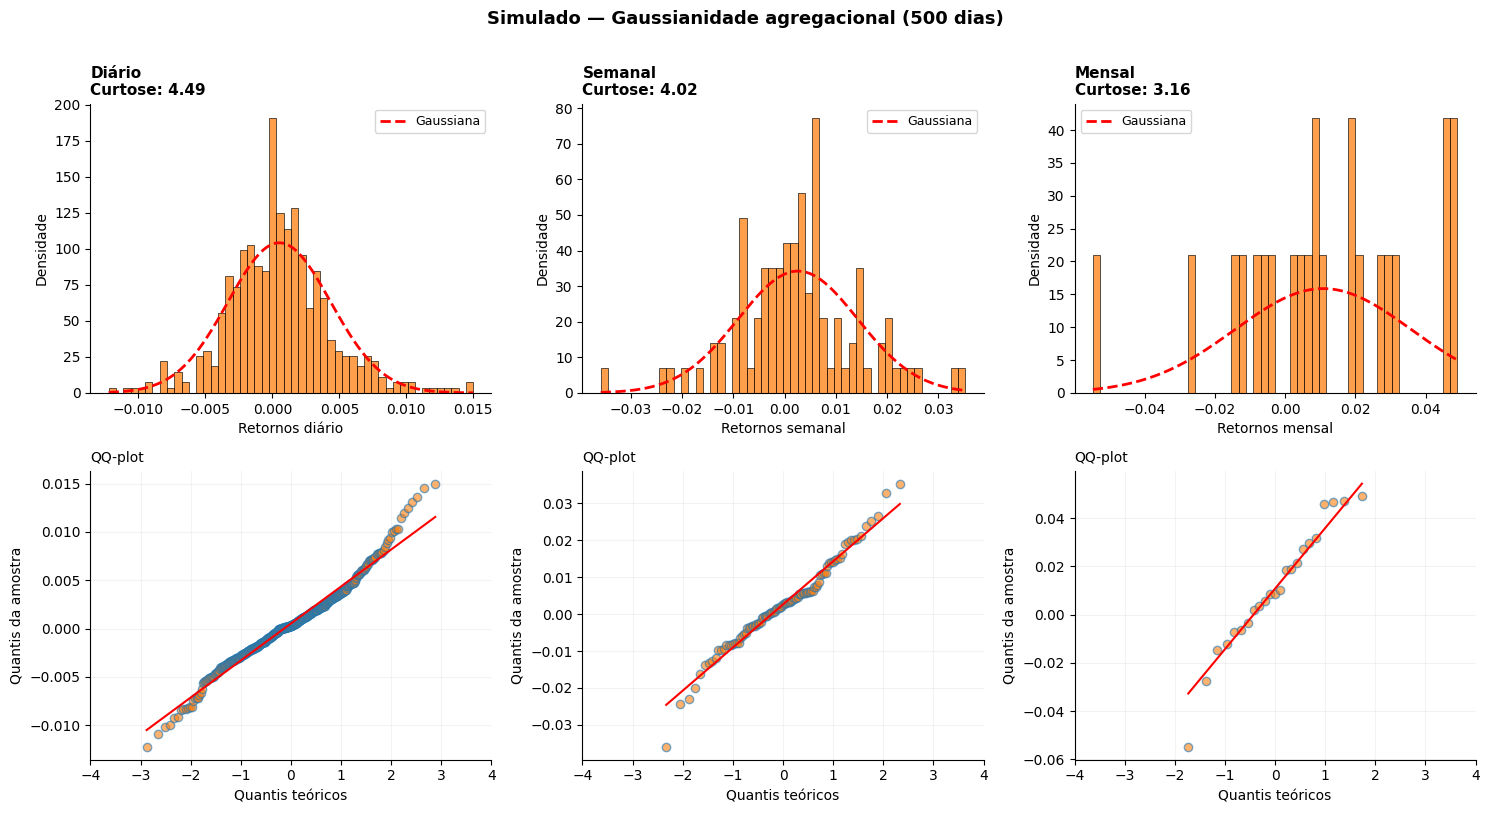

Curtose Diário: 4.4865
Curtose Semanal: 4.0244
Curtose Mensal: 3.1625

Curtoses IFIX:     {'Diário': '10.8459', 'Semanal': '18.3111', 'Mensal': '3.0676'}
Curtoses Simulado: {'Diário': '4.4865', 'Semanal': '4.0244', 'Mensal': '3.1625'}


In [36]:
# Fato 06 — Gaussianidade agregacional
fig1, curtoses_ifix = plot_gaussianidade_agregacional(
    retorno_diario_bench[-NUM_DIAS:],
    escalas=[1, 5, 21],
    labels_escalas=["Diário", "Semanal", "Mensal"],
    titulo="IFIX — Gaussianidade agregacional (500 dias)",
    cor="tab:blue"
)

fig2, curtoses_sim = plot_gaussianidade_agregacional(
    log_return_500[-NUM_DIAS:],
    escalas=[1, 5, 21],
    labels_escalas=["Diário", "Semanal", "Mensal"],
    titulo="Simulado — Gaussianidade agregacional (500 dias)",
    cor="tab:orange"
)

print("\nCurtoses IFIX:    ", {l: f"{k:.4f}" for l, k in zip(["Diário","Semanal","Mensal"], curtoses_ifix)})
print("Curtoses Simulado:", {l: f"{k:.4f}" for l, k in zip(["Diário","Semanal","Mensal"], curtoses_sim)})

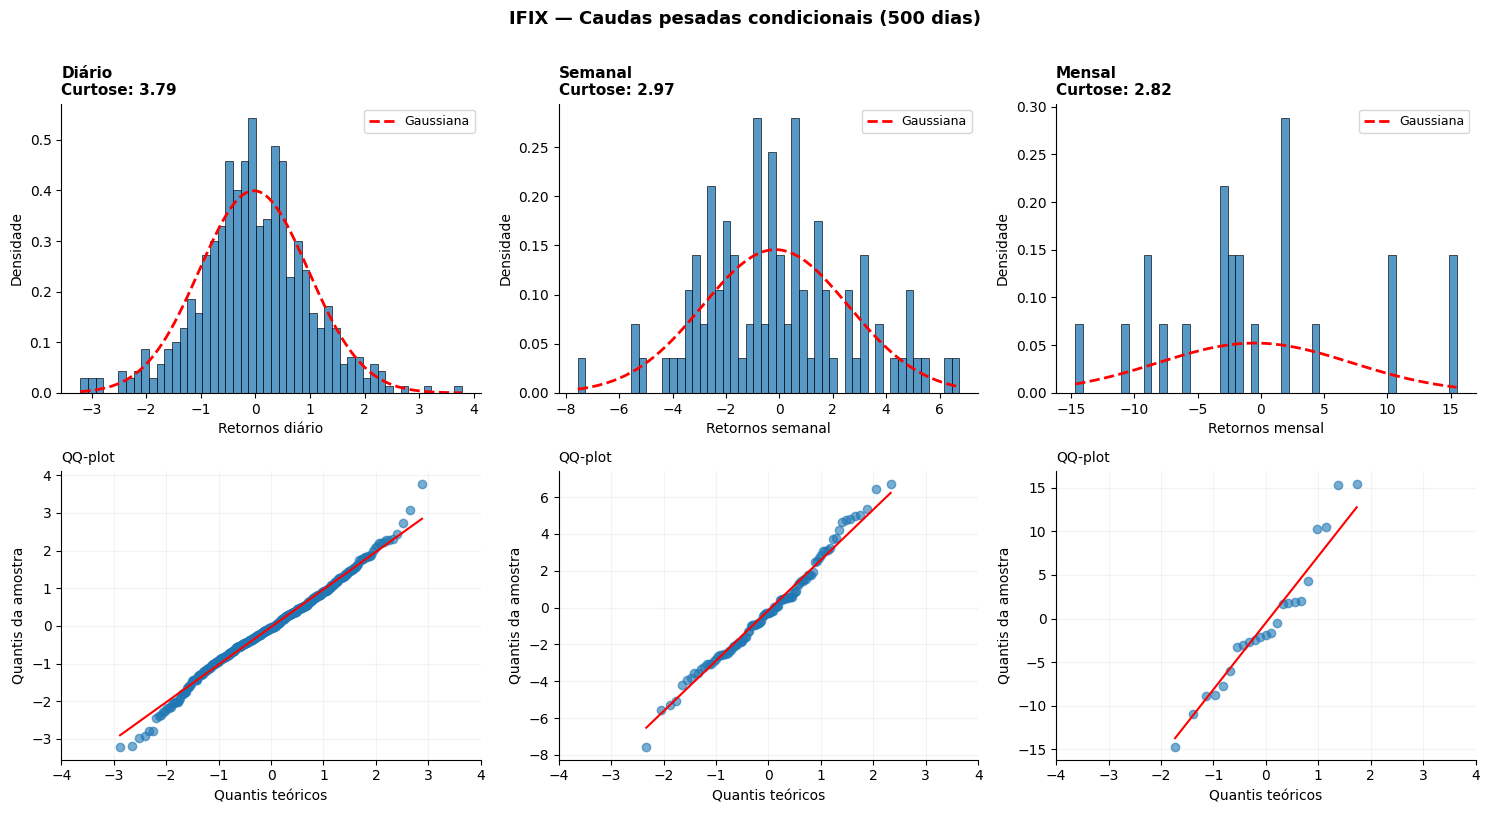

Curtose Diário: 3.7875
Curtose Semanal: 2.9736
Curtose Mensal: 2.8155


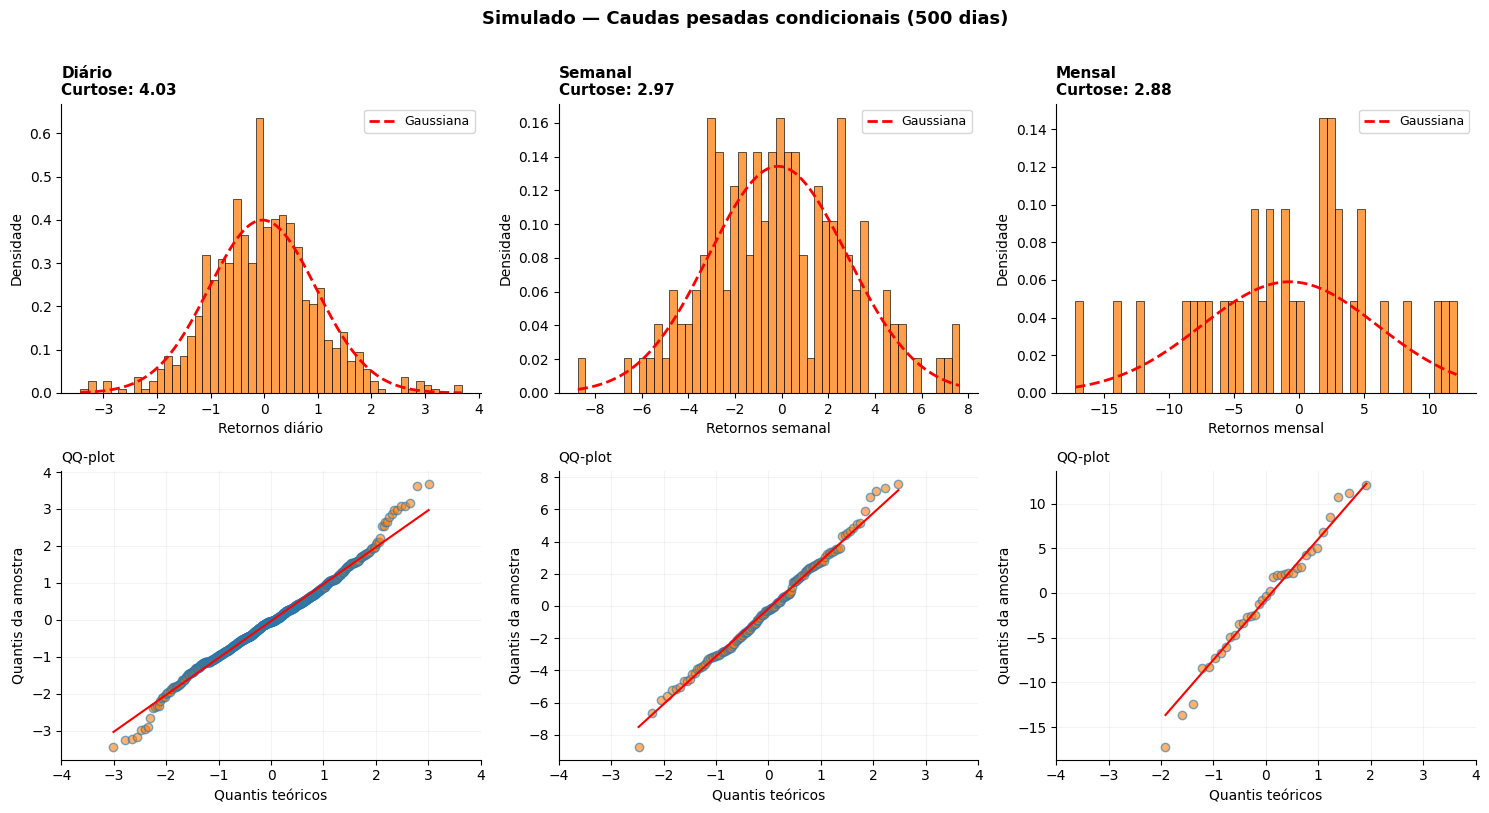

Curtose Diário: 4.0278
Curtose Semanal: 2.9700
Curtose Mensal: 2.8789

Curtoses resíduos IFIX:     {'Diário': '3.7875', 'Semanal': '2.9736', 'Mensal': '2.8155'}
Curtoses resíduos Simulado: {'Diário': '4.0278', 'Semanal': '2.9700', 'Mensal': '2.8789'}


In [37]:
# Fato 07 — Caudas pesadas condicionais (resíduos GARCH — 500 dias)
residuos_ifix_500 = calcular_residuos_garch(retorno_diario_bench[-500:], escalas=[1, 5, 21])
residuos_sim_500  = calcular_residuos_garch(log_return_500,               escalas=[1, 5, 21])

fig1, curtoses_ifix = plot_gaussianidade_agregacional(
    residuos_ifix_500[0],
    escalas=[1, 5, 21],
    labels_escalas=["Diário", "Semanal", "Mensal"],
    titulo="IFIX — Caudas pesadas condicionais (500 dias)",
    cor="tab:blue"
)

fig2, curtoses_sim = plot_gaussianidade_agregacional(
    residuos_sim_500[0],
    escalas=[1, 5, 21],
    labels_escalas=["Diário", "Semanal", "Mensal"],
    titulo="Simulado — Caudas pesadas condicionais (500 dias)",
    cor="tab:orange"
)

print("\nCurtoses resíduos IFIX:    ", {l: f"{k:.4f}" for l, k in zip(["Diário","Semanal","Mensal"], curtoses_ifix)})
print("Curtoses resíduos Simulado:", {l: f"{k:.4f}" for l, k in zip(["Diário","Semanal","Mensal"], curtoses_sim)})